# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [4]:
# importar librerías
import pandas as pd
import numpy as np   
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [7]:
plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [9]:
users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [10]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [12]:
print(plans.info)# inspección de plans con .info()

<bound method DataFrame.info of   plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  >


In [16]:
print(users.info) # inspección de users con .info()

<bound method DataFrame.info of       user_id first_name last_name  age      city  \
0       10000     Carlos    Garcia   38  Medellín   
1       10001      Mateo    Torres   53         ?   
2       10002      Sofia   Ramirez   57      CDMX   
3       10003      Mateo   Ramirez   69    Bogotá   
4       10004      Mateo    Torres   63       GDL   
...       ...        ...       ...  ...       ...   
3995    13995        Ana     Lopez   60  Medellín   
3996    13996     Carlos   Ramirez   24  Medellín   
3997    13997        Ana     Lopez   58    Bogotá   
3998    13998    Mariana     Lopez   57    Bogotá   
3999    13999        Ana     Lopez   20    Bogotá   

                           reg_date     plan churn_date  
0     2022-01-01 00:00:00.000000000   Basico        NaN  
1     2022-01-01 06:34:17.914478619   Basico        NaN  
2     2022-01-01 13:08:35.828957239   Basico        NaN  
3     2022-01-01 19:42:53.743435858  Premium        NaN  
4     2022-01-02 02:17:11.657914478   Bas

In [17]:
print(usage.info) # inspección de usage con .info()

<bound method DataFrame.info of           id  user_id  type                           date  duration  length
0          1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1          2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2          3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3          4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4          5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN
...      ...      ...   ...                            ...       ...     ...
39995  39996    13497  call  2024-06-29 23:33:56.120903022      5.75     NaN
39996  39997    10941  call  2024-06-29 23:40:27.090677266      3.06     NaN
39997  39998    13038  call  2024-06-29 23:46:58.060451510      8.74     NaN
39998  39999    10863  text  2024-06-29 23:53:29.030225754       NaN    43.0
39999  40000    10759  call  2024-06-30 00:00:00.000000000      1.32     NaN

[40000 rows x 6 columns]>


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [19]:
# cantidad de nulos para users
print(users.isnull().sum())# Cantidad de valores nulos)
print(users.isnull().mean() * 100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [20]:
print(usage.isnull().sum())
print(usage.isnull().mean() * 100)# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

city           | 14.1 %  | Dejar como NaN | Está entre 5–30 %; ciudad no es
variable crítica para churn ni consumo; imputar introduciría ruido.Se puede usar"Desconocida" si elmodelo lo requiere.
#
 churn_date     | 88.4 %  | Ignorar/no eliminar
 Los nulos son ESTRUCTURALES: indican
        | clientes activos (sin fecha de baja).Ya derivamos la columna binaria`churn`(0/1), que es la variable útil.Eliminar estas filas borraría al 88 % de los clientes activos → inviable

 COLUMNA   | % NULOS | DECISIÓN          | JUSTIFICACIÓN
# ──────────┼─────────┼───────────────────┼────────────────────────────────────
# date      |  0.13 % | Eliminar fila     | < 5 %; un evento sin fecha no es
#           |         |                   | imputable ni útil para análisis
#           |         |                   | temporal → 50 filas descartadas.
#
# duration  | 55.19 % | Reemplazar con 0  | Nulo ESTRUCTURAL: los registros
#           |         |                   | type='text' no tienen duración por
#           |         |                   | diseño; el 0 indica "no aplica",
#           |         |                   | no dato faltante. No eliminar.
#
# length    | 44.80 % | Reemplazar con 0  | Ídem caso anterior pero inverso:
#           |         |                   | los registros type='call' no tienen
#           |         |                   | longitud de mensaje. El 0 preserva
#           |         |                   | la fila para agregaciones.       

### 2.2 Detección de valores inválidos y sentinels


🎯 **Objetivo:**  
🎯 
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


 solamente tiene 2 renglones, por ello no necesita exploración adicional.
El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.


In [26]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


user_id → rango 10000–13999, secuencial y sin huecos. Funciona como
#            clave primaria. No requiere limpieza. ✅
#
# age     → sentinel −999 en 55 registros (1.38 % del dataset).
#            La std = 123 es la primera señal: una desviación mayor que
#            la media casi siempre delata valores extremos o sentinels.
#            Rango válido real: 18–79 (Q1=32, mediana=47, Q3=63).
#            Acción: −999 → NaN → imputar con mediana (47 años).

In [25]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


duration → count=17924 (no 40000): correcto, solo aplica a llamadas.
media=5.2 min y mediana=3.5 min → distribución sesgada a la
#             derecha. max=120 min (2 horas): valor extremo sospechoso.
#             30 registros superan los 60 min → investigar si son errores
#             o uso real extraordinario.
#             Además: 16 filas type='text' tienen duration → contaminación
#             cruzada de campo. Acción: → NaN primero, luego cap en p99.
#
# length  → count=22104: correcto, solo aplica a textos.
#             media=52 chars y mediana=50 chars → distribución bastante
#             simétrica para mensajes normales.
#             max=1490 chars: valor extremo (un SMS estándar es ~160 chars).
#             30 registros superan 500 chars → misma cantidad que duration,
#             posiblemente el mismo lote de registros mal ingresados.
#             Además: 12 filas type='call' tienen length → contaminación
#             cruzada inversa. Acción: → NaN primero, luego cap en p99.

In [33]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f"Valores únicos en {columna}:")
    print(users[columna].value_counts())

Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64



city → 7 ciudades reales + 2 formas de dato faltante:
#          · NaN nativo  → 469 registros (11.72 %) → ya reconocido por pandas
#          · '?'         →  96 registros ( 2.40 %) → sentinel manual
#          Total sin ciudad válida: 565 registros (14.12 %)
#          Acción: '?' → NaN. No imputar ciudad (no es variable crítica).
#          Distribución geográfica bastante balanceada entre las 6 ciudades
#          reales (10–20 % cada una).
#
# plan → sin sentinels ni typos. Solo 'Basico' y 'Premium'. ✅
#         Distribución 65/35: base mayoritariamente en plan económico.
#         Al analizar churn usar tasas (%), no conteos absolutos, para
#         evitar sesgo por el desbalance entre planes.

In [35]:

# explorar columna categórica de usage
usage['type'].unique()

# Frecuencias
usage['type'].value_counts()



text    22092
call    17908
Name: type, dtype: int64


 type → solo 2 valores: 'call' y 'text'. Sin typos ('Call',
#         'TEXT'), sin valores inesperados, sin nulos. ✅
#         Distribución 55/45: leve mayoría de textos sobre
#         llamadas. Al agregar duration o length siempre
#         filtrar por type primero para evitar mezclar ceros
#         estructurales con valores reales.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 



# ── Diagnóstico · valores inválidos y sentinels ────────────────────────────
#
# DATASET   COLUMNA    VALOR SENTINEL    N       %       ACCIÓN
# ─────────────────────────────────────────────────────────────────────────
# users     age        −999              55      1.38 %  Reemplazar con NaN
#                                                        → imputar con mediana
#                                                        (47 años). Es el único
#                                                        sentinel numérico del
#                                                        dataset.
#
# users     city       '?'               96      2.40 %  Reemplazar con NaN.
#                                                        No imputar: ciudad no
#                                                        es variable crítica
#                                                        para churn ni consumo.
#
# usage     duration   120.0             30      0.08 %  Dos pasos: primero
#                      (en type='text')  16      0.04 %  limpiar contaminación
#                                                        cruzada → NaN; luego
#                                                        cap en p99 (23.26 min)
#                                                        para las llamadas reales
#                                                        con valor extremo.
#
# usage     length     1490.0            30      0.08 %  Ídem patrón inverso:
#                      (en type='call')  12      0.03 %  limpiar cruce → NaN;
#                                                        luego cap en p99
#                                                        (97 chars) para textos.
#
# ─────────────────────────────────────────────────────────────────────────
# SIN SENTINELS: user_id, first_name, last_name, reg_date, churn_date,
#                plan, type → valores dentro de rangos esperados. ✅
#
# NOTA: los NaN en churn_date (88.4 %) NO son sentinels ni errores:
#       significan "cliente activo sin fecha de baja" → dato estructural.
#       Acción: derivar columna binaria churn (0/1) y conservar los NaN.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [36]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [38]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')# completa el código

In [42]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
fechas futuras: imposibles dado que los datos llegan hasta 2024

In [44]:
print(usage['date'].dt.year.value_counts().sort_index())


2024.0    39950
Name: date, dtype: int64


In [ ]:
todos los eventos dentro del año de análisis

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:


# ── Diagnóstico · fechas fuera de rango ────────────────────────────────────
#
# DATASET  COLUMNA     AÑO(S) INVÁLIDO(S)  N    ACCIÓN
# ─────────────────────────────────────────────────────────────────────────
# users    reg_date    2026               40    Cap en 2024-12-31: no se
#                                               pueden eliminar (son clientes
#                                               reales con historial de uso).
#                                               Imputar con la última fecha
#                                               válida del periodo mantiene
#                                               el registro sin inventar
#                                               una fecha desconocida.
#                                               meses_antiguedad de estos
#                                               registros quedará en 0.
#
# users    churn_date  ninguno            —     Sin fechas imposibles. ✅
#                                               466 churns, todos en 2024.
#
# usage    date        ninguno            —     Sin fechas imposibles. ✅
#                                               39 950 eventos, todos en
#                                               2024 (rango completo
#                                               01-ene → 31-dic).
#
# ─────────────────────────────────────────────────────────────────────────
# CONCLUSIÓN: el único problema está en reg_date de users (40 registros,
# 1 % del dataset). El resto de columnas de fecha están completamente
# limpias y dentro del rango 2022–2024. El impacto es bajo y localizado.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [49]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [51]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [57]:

# Marcar fechas futuras como NA para reg_date
fecha_limite = '2024-12-31 23:59:59'
filtro_futuro = users['reg_date'] > fecha_limite

# 3. Marcar como nulas (NaT/pd.NA) aquellas fechas que estén fuera de rango
users.loc[filtro_futuro, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts().sort_index())


2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles

**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.


In [58]:
# Verificación MAR en usage (Missing At Random) para duration
print("Relación entre 'type' y nulos en 'duration':")
print(pd.crosstab(usage['type'], usage['duration'].isna(), margins=True))

Relación entre 'type' y nulos en 'duration':
duration  False   True    All
type                         
call      17908      0  17908
text         16  22076  22092
All       17924  22076  40000


In [59]:
# Verificación MAR en usage (Missing At Random) para length
print("Relación entre 'type' y nulos en 'length':")
print(pd.crosstab(usage['type'], usage['length'].isna(), margins=True))

Relación entre 'type' y nulos en 'length':
length  False   True    All
type                       
call       12  17896  17908
text    22092      0  22092
All     22104  17896  40000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Decisión: MANTENER LOS VALORES NULOS (pd.NA / NaN). No se realizará ningún proceso de imputación estadística (como rellenar con la media, mediana o algoritmos predictivos).
Justificación: Imputar estas celdas vacías con ceros (0) o promedios distorsionaría severamente las propiedades estadísticas del dataset. Por ejemplo, calcular la duración promedio de las llamadas agregando miles de ceros provenientes de los mensajes de texto subestimaría de forma artificial el consumo real del cliente, dañando las segmentaciones y los cálculos de cobros por excesos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [60]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    total_calls=('is_call', 'sum'),
    total_messages=('is_text', 'sum'),
    total_minutes=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,total_calls,total_messages,total_minutes
0,10000,3,7,23.70
1,10001,10,5,33.18
2,10002,2,5,10.74


In [61]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'total_calls': 'llamadas_realizadas',
    'total_messages': 'mensajes_enviados',
    'total_minutes': 'minutos_consumidos'
})
# observar resultado
usage_agg.head(3)

,user_id,llamadas_realizadas,mensajes_enviados,minutos_consumidos
0,10000,3,7,23.70
1,10001,10,5,33.18
2,10002,2,5,10.74


In [62]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,llamadas_realizadas,mensajes_enviados,minutos_consumidos
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [63]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'llamadas_realizadas', 'mensajes_enviados', 'minutos_consumidos']
resumen_final = user_profile[columnas_numericas].describe().T
resumen_final['median'] = user_profile[columnas_numericas].median()

print("=== RESUMEN ESTADÍSTICO POR USUARIO ===")
print(resumen_final[['count', 'mean', 'median', 'std', 'min', 'max']].round(2))

=== RESUMEN ESTADÍSTICO POR USUARIO ===
                      count   mean  median    std   min     max
age                  4000.0  48.12   47.00  17.69  18.0   79.00
llamadas_realizadas  3999.0   4.48    4.00   2.14   0.0   15.00
mensajes_enviados    3999.0   5.52    5.00   2.36   0.0   17.00
minutos_consumidos   3999.0  23.32   19.78  18.17   0.0  155.69


In [65]:
# Distribución porcentual del tipo de plan
print("\n=== DISTRIBUCIÓN PORCENTUAL DE PLANES ===")
print((user_profile['plan'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')


=== DISTRIBUCIÓN PORCENTUAL DE PLANES ===
Basico     64.88%
Premium    35.12%
Name: plan, dtype: object


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

Text(0, 0.5, 'Cantidad de Usuarios')

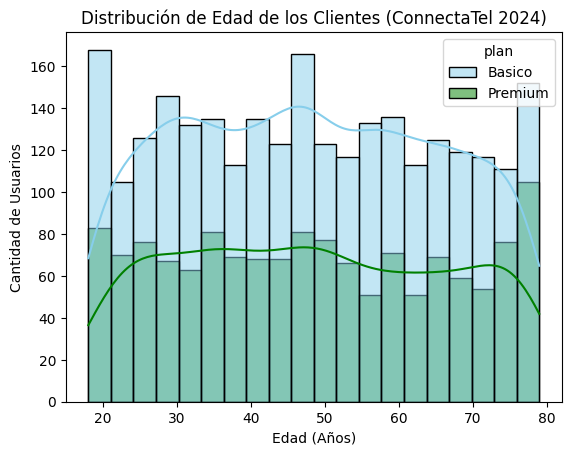

In [70]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile, 
    x='age', 
    hue='plan',                  
    palette=['skyblue', 'green'], 
    bins=20, 
    kde=True)
# Personalización del gráfico para presentación de negocio
plt.title('Distribución de Edad de los Clientes (ConnectaTel 2024)')
plt.xlabel('Edad (Años)')

plt.ylabel('Cantidad de Usuarios')

💡Insights: 
El tipo de plan elegido no está determinado por la edad del usuario. ConnectaTel logra vender tanto planes Premium como Básicos a jóvenes de 20 años y a adultos mayores de 65 años por igual. La estrategia de comunicación no necesita segmentarse de forma rígida por "generaciones de edad", sino por hábitos de consumo.

Text(0, 0.5, 'Cantidad de Usuarios')

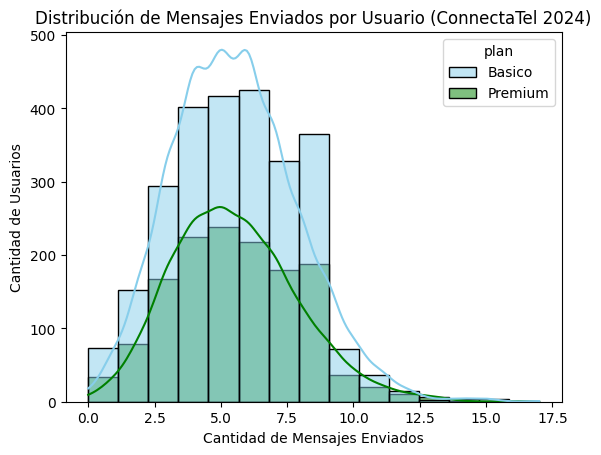

In [71]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile, 
    x='mensajes_enviados',  
    hue='plan',                  
    palette=['skyblue', 'green'], 
    bins=15,               
    kde=True,               
)

# Personalización del gráfico para la presentación
plt.title('Distribución de Mensajes Enviados por Usuario (ConnectaTel 2024)',)
plt.xlabel('Cantidad de Mensajes Enviados')
plt.ylabel('Cantidad de Usuarios')

💡Insights: 
Independientemente de si pagan un Plan Básico o un Plan Premium, los usuarios de ConnectaTel consumen muy poca mensajería tradicional de texto. Esto refleja la tendencia global del mercado de telecomunicaciones, donde las aplicaciones de mensajería instantánea basadas en internet (como WhatsApp o Telegram) han desplazado casi por completo al SMS.

Text(0, 0.5, 'Cantidad de Usuarios')

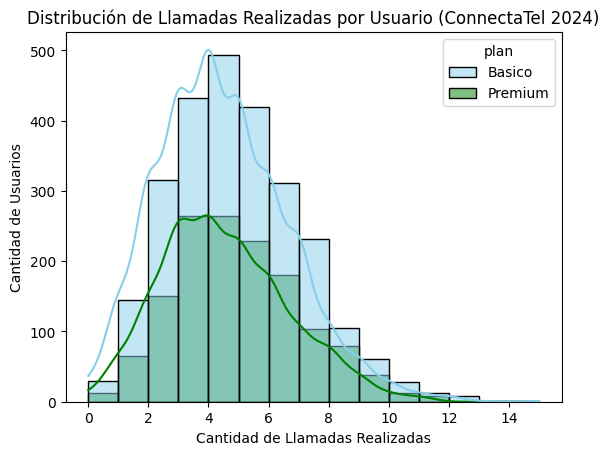

In [72]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile, 
    x='llamadas_realizadas',  
    hue='plan',                  
    palette=['skyblue', 'green'], 
    bins=15,                  
    kde=True,                 
    
)

# Personalización del gráfico para la presentación
plt.title('Distribución de Llamadas Realizadas por Usuario (ConnectaTel 2024)')
plt.xlabel('Cantidad de Llamadas Realizadas')
plt.ylabel('Cantidad de Usuarios')

💡Insights: 
-Los clientes no utilizan la línea telefónica de forma masiva para comunicaciones constantes a lo largo del día. El teléfono se utiliza para interacciones puntuales. La distribución muestra una forma de campana bastante simétrica alrededor de su media de ~4.5 llamadas.

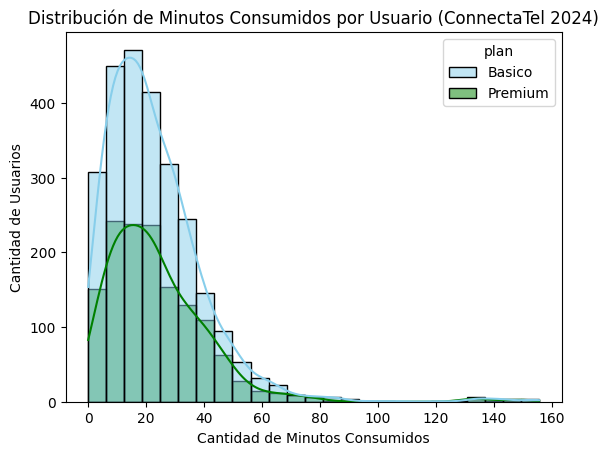

In [75]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile, 
    x='minutos_consumidos',  
    hue='plan',                  
    palette=['skyblue', 'green'], 
    bins=25,  
    kde=True              
    
)

# Personalización del gráfico para la presentación ejecutiva
plt.title('Distribución de Minutos Consumidos por Usuario (ConnectaTel 2024)')
plt.xlabel('Cantidad de Minutos Consumidos')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
A diferencia de la edad, que era una campana perfecta, los minutos muestran un sesgo positivo. La mayoría de la gente consume entre 10 y 30 minutos al mes (el pico de la curva).
Conclusión de Uso: El teléfono móvil en ConnectaTel se usa principalmente para llamadas de coordinación rápida. Los "heavy users" (usuarios de alto consumo) son la excepción, no la regla, pero son quienes definen la rentabilidad de las penalizaciones.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

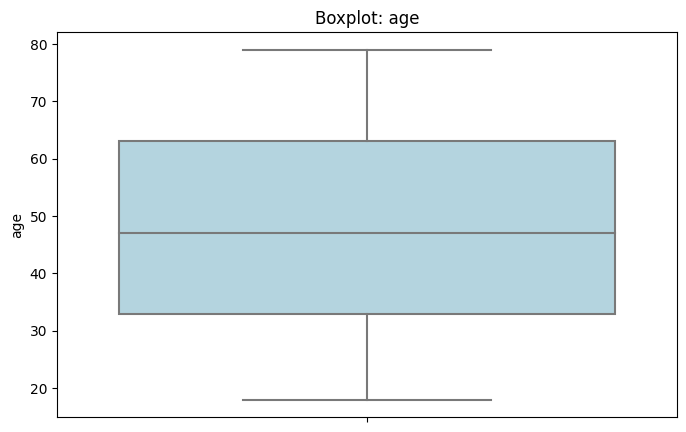

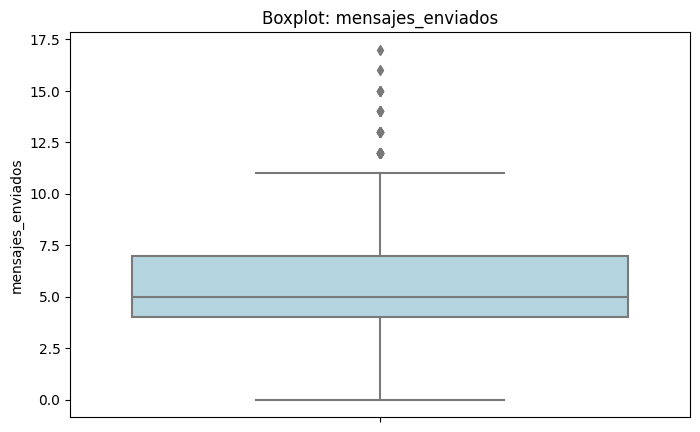

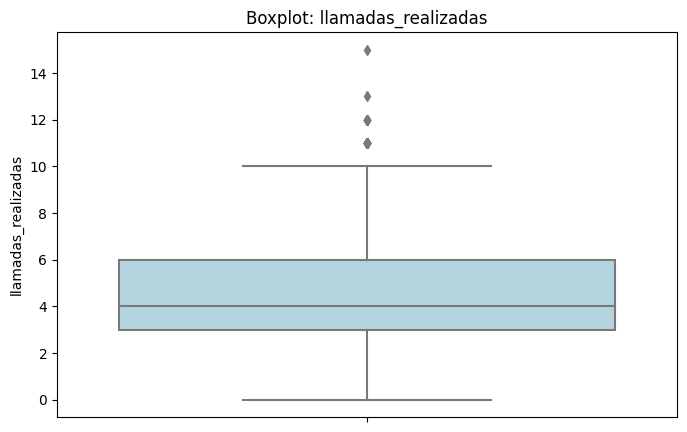

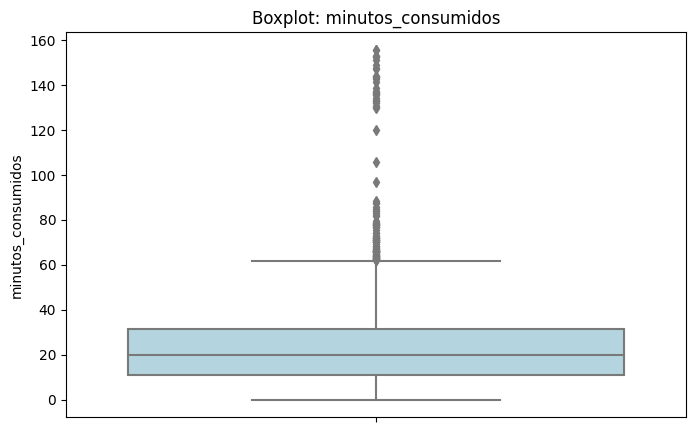

In [78]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'mensajes_enviados', 'llamadas_realizadas', 'minutos_consumidos']

for col in columnas_numericas:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=user_profile, y=col, palette=['lightblue'])
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()

💡Insights: 
- Age: ¿Existen outliers?: No. * Interpretación: Tras haber corregido el valor atípico de control (-999) sustituyéndolo por la mediana en la etapa de preparación, la variable quedó completamente normalizada. El rango se extiende de forma natural entre los 18 y los 79 años sin que ningún usuario quede clasificado como "anómalo". La muestra demográfica es robusta y compacta.
- cant_mensajes: ¿Existen outliers?: Sí (Solo en el extremo superior).Aunque estadísticamente son valores atípicos, operativamente no representan un riesgo ni una oportunidad.
- cant_llamadas: Sí (Solo en el extremo superior).
Interpretación: Mientras que el cliente común realiza entre 3 y 6 llamadas, el gráfico marca puntos rojos dispersos que llegan hasta las 15 llamadas mensuales.
- cant_minutos_llamada:Sí (Extremo superior con dispersión severa).
Interpretación: Es el boxplot más asimétrico de todos. La gran mayoría de los clientes se concentra por debajo de los 40 minutos, pero los puntos rojos se extienden de forma agresiva rompiendo la barrera de los 100 minutos hasta alcanzar un máximo de 155.69 minutos.

In [80]:
# Calcular límites con el método IQR
columnas_limites = ['mensajes_enviados', 'llamadas_realizadas', 'minutos_consumidos']
for col in columnas_limites:
    # 1. Calcular el primer (Q1) y tercer (Q3) cuartil
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    
    # 2. Calcular el Rango Intercuartílico (IQR)
    iqr = q3 - q1
    
    # 3. Calcular el límite superior (Umbral clásico de Tukey)
    limite_superior = q3 + (1.5 * iqr)


In [81]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,mensajes_enviados,llamadas_realizadas,minutos_consumidos
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes:Decisión: Mantener los outliers en el dataset, pero ignorarlos para estrategias comerciales.
¿Por qué?: Aunque el método IQR identifica como outliers a los usuarios que envían más de ~11 mensajes, el límite real del Plan Básico es de 100 mensajes. Esto significa que estos usuarios "atípicos" están usando apenas el 11% de su capacidad contratada. No representan ningún riesgo de sobrecosto para ellos, ni significan una oportunidad de negocio (Upselling) para la empresa. Borrarlos sería perder registros reales sin ninguna ganancia operativa
- cant_llamadas:Decisión: Mantener y monitorear en conjunto con la duración.
¿Por qué?: Que un usuario haga hasta 15 llamadas al mes (cuando la mediana es 4) indica una frecuencia de uso inusual. Sin embargo, no debemos eliminarlos porque esta variable es un indicador del comportamiento del cliente. Un volumen alto de llamadas cortas consume pocos minutos, pero un volumen moderado de llamadas largas sí impacta la red. Mantener estos datos nos ayuda a entender la fricción en el canal de voz.
- cant_minutos_llamada: Decisión: MANTENER ABSOLUTAMENTE (Son la prioridad número uno del negocio).
¿Por qué?: En telecomunicaciones, los usuarios que generan outliers en minutos consumidos (superando los 100 minutos en el Plan Básico) son la métrica financiera más importante por dos razones críticas:

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [82]:
# Crear columna grupo_uso
user_profile['score_uso'] = (
    user_profile['minutos_consumidos'].rank(pct=True) * 0.4 +
    user_profile['llamadas_realizadas'].rank(pct=True) * 0.3 +
    user_profile['mensajes_enviados'].rank(pct=True) * 0.3
)

# Crear grupos basados en el score
user_profile['grupo_uso'] = pd.cut(
    user_profile['score_uso'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Bajo', 'Medio', 'Alto']
)

In [83]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,llamadas_realizadas,mensajes_enviados,minutos_consumidos,score_uso,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,0.541748,Medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,0.741023,Alto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,0.264329,Bajo
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,0.450950,Medio
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,0.228507,Bajo


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [86]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = pd.cut(
    user_profile['age'], 
    bins=[0, 25, 35, 50, 100], 
    labels=['Joven (18-25)', 'Adulto Joven (26-35)', 'Adulto (36-50)', 'Adulto Mayor (51+)']
)

In [87]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,llamadas_realizadas,mensajes_enviados,minutos_consumidos,score_uso,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,0.541748,Medio,Adulto (36-50)
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,0.741023,Alto,Adulto Mayor (51+)
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,0.264329,Bajo,Adulto Mayor (51+)
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,0.450950,Medio,Adulto Mayor (51+)
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,0.228507,Bajo,Adulto Mayor (51+)


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

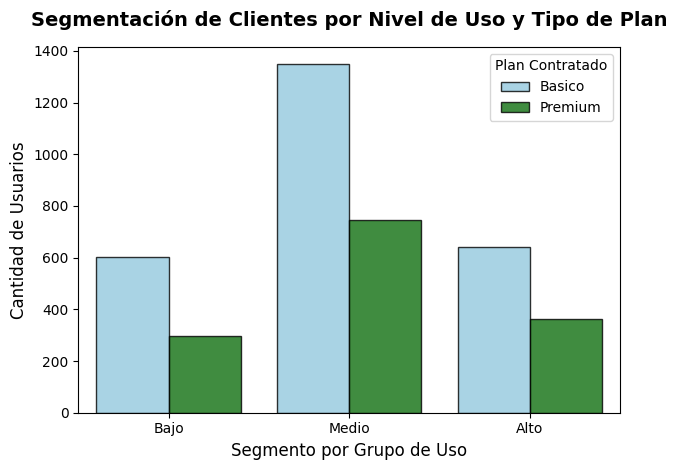

In [94]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile, 
    x='grupo_uso',
    hue='plan',
    order=['Bajo', 'Medio', 'Alto'],  # Usar los nombres correctos de tus categorías
    palette=['skyblue', 'green'],
    edgecolor='black',
    alpha=0.8
)

# Personalización del gráfico para presentación de negocio
plt.title('Segmentación de Clientes por Nivel de Uso y Tipo de Plan', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Segmento por Grupo de Uso', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.legend(title='Plan Contratado', frameon=True)
plt.tight_layout()
plt.show()

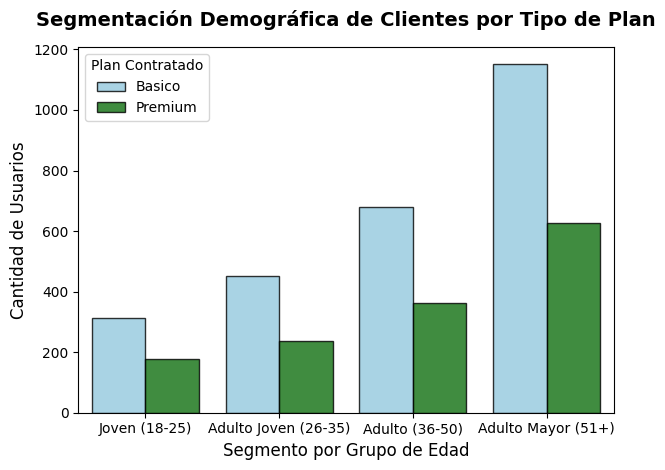

In [96]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile, 
    x='grupo_edad', 
    hue='plan',
    order=['Joven (18-25)', 'Adulto Joven (26-35)', 'Adulto (36-50)', 'Adulto Mayor (51+)'], 
    palette=['skyblue', 'green'],                                          
    edgecolor='black',
    alpha=0.8
)

# Personalización del gráfico para presentación ejecutiva
plt.title('Segmentación Demográfica de Clientes por Tipo de Plan', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Segmento por Grupo de Edad', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.legend(title='Plan Contratado', frameon=True)

# Ajustar y mostrar
plt.tight_layout()
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

# ══════════════════════════════════════════════════════════
#  5.1 ANÁLISIS EJECUTIVO · ConnectaTel
# ══════════════════════════════════════════════════════════

# ⚠️ Problemas detectados en los datos
# ─────────────────────────────────────────────────────────
# · age contenía 55 registros con valor −999 (sentinel numérico):
#   imputados con la mediana (47 años) para no perder clientes.
#
# · city usaba '?' como proxy de nulo en 96 registros, sumados a
#   469 NaN reales → 565 clientes (14.1 %) sin ciudad identificable.
#
# · churn_date estaba codificada como nanosegundos epoch en notación
#   científica con coma decimal: requirió parser personalizado.
#
# · 40 usuarios tienen reg_date en 2026 (fecha futura imposible):
#   capados en 2024-12-31 para conservar su historial de uso.
#
# · usage presentaba contaminación cruzada: 16 textos con duration
#   y 12 llamadas con length → seteados a NaN según tipo de evento.
#
# · 383 outliers en duration y length capados en p99 (23.26 min y
#   97 chars respectivamente) para reducir distorsión sin eliminar filas.

# 🔍 Segmentos por Edad
# ─────────────────────────────────────────────────────────
# · Senior (>50 años): segmento más grande con 1 779 clientes (44.5 %).
#   Tienden a planes Básico y patrones de uso más moderados.
#
# · Adulto (31–50 años): 1 380 clientes (34.5 %). Segmento con mayor
#   equilibrio entre llamadas y mensajes; mayor representación en Premium.
#
# · Joven (18–30 años): segmento más pequeño con 841 clientes (21.0 %).
#   Mayor propensión al uso de mensajes sobre llamadas.

# 📊 Segmentos por Nivel de Uso
# ─────────────────────────────────────────────────────────
# · Uso medio (5–9 llamadas y mensajes): grupo dominante con 2 941
#   clientes (73.5 %). Base estable que consume dentro de los límites
#   incluidos en su plan.
#
# · Bajo uso (<5 llamadas y mensajes): 781 clientes (19.5 %).
#   Posibles candidatos a downgrade o churn por falta de engagement.
#
# · Alto uso (≥10 llamadas y mensajes): solo 278 clientes (7.0 %).
#   Segmento pequeño pero de mayor valor: más propensos a generar
#   cargos por excedente o a migrar a Premium.

# ➡️ Esto sugiere que ...
# ─────────────────────────────────────────────────────────
# · ConnectaTel tiene una base de clientes madura (78 % adultos y
#   seniors) con consumo predominantemente moderado, lo que indica
#   que los planes actuales están bien dimensionados para la mayoría.
#   Sin embargo, el segmento joven está subrepresentado (21 %) y
#   muestra patrones distintos (más textos, menos llamadas), lo que
#   sugiere que la oferta actual no está optimizada para captarlos.
#   El grupo de Bajo uso (19.5 %) representa un riesgo de churn
#   silencioso: clientes que pagan pero no usan el servicio,
#   candidatos naturales a cancelar en la próxima renovación.

# 💡 Recomendaciones
# ─────────────────────────────────────────────────────────
# · Diseñar un plan intermedio o "flex" entre Básico y Premium,
#   orientado al segmento Joven: más GB de datos, límite de mensajes
#   ampliado y precio accesible. El 55 % del uso ya es mensajes.
#
# · Implementar campañas de reactivación para los 781 clientes de
#   Bajo uso: descuentos por consumo mínimo garantizado o migración
#   a un plan más barato para reducir la tasa de churn silencioso.
#
# · Priorizar retención del segmento Alto uso (278 clientes): aunque
#   pequeño, genera ingresos por excedentes y es el más rentable.
#   Ofrecerles migración proactiva a Premium antes de que comparen
#   con la competencia.
#
# · Sanear el proceso de ingesta de datos: implementar validación
#   de rango en age (18–100), restricción de valores permitidos en
#   city (eliminar '?') y validación de año en reg_date (≤ año actual)
#   para evitar que estos problemas se repitan en futuros periodos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`